# Employee Retention and Attrition Prediction

This notebook builds a production-style attrition classifier from the employee dataset. `Left` is verified as the positive attrition class and `Stayed` as retention. The final artifact contains preprocessing, model, feature schema, class mapping, and configurable risk thresholds.

## Data inspection and cleaning

The dataset has mixed numeric/categorical features, missing distance and tenure values, 112 exact duplicate rows, and mojibake in degree labels. Exact duplicate rows are removed before splitting to prevent repeated observations crossing evaluation boundaries. Employee ID is excluded as an identifier.

In [ ]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
    train_test_split, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = next(parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'ml' / 'data').exists())
DATA_PATH = PROJECT_ROOT / 'ml' / 'data' / 'Emp_attrition_csv.csv'
MODEL_DIR = PROJECT_ROOT / 'ml' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH, low_memory=False)
print('shape:', df.shape)
print('columns:', df.columns.tolist())
display(df.head())
display(df.sample(5, random_state=42))
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().loc[lambda values: values.gt(0)].to_frame('missing'))
print('duplicate rows:', int(df.duplicated().sum()))
print('target values:', df['Attrition'].value_counts(dropna=False).to_dict())
print('employee IDs:', df['Employee ID'].nunique(), 'rows:', len(df))

shape: (74610, 24)
columns: ['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
71975,71730,36,Female,18,Media,6199,Poor,High,Below Average,1,...,0,Mid,Large,54.0,No,No,No,Poor,High,Left
20692,10008,20,Male,9,Healthcare,7456,Excellent,High,Average,1,...,1,Senior,Small,16.0,No,No,Yes,Excellent,High,Stayed
21753,72965,47,Female,33,Education,4744,Excellent,Medium,Average,0,...,2,Mid,Medium,40.0,No,No,Yes,Good,Low,Stayed
16382,27109,49,Male,35,Healthcare,8807,Fair,High,Average,0,...,4,Mid,Medium,53.0,Yes,No,No,Excellent,Low,Stayed
58800,73921,58,Female,48,Finance,7114,Poor,High,Average,1,...,3,Mid,Medium,78.0,Yes,No,No,Good,Medium,Stayed


,dtype
Employee ID,int64
Age,int64
Gender,object
Years at Company,int64
Job Role,object
Monthly Income,int64
Work-Life Balance,object
Job Satisfaction,object
Performance Rating,object
Number of Promotions,int64


,missing
Distance from Home,1912
Company Tenure (In Months),2413


duplicate rows: 112
target values: {'Stayed': 39191, 'Left': 35419}
employee IDs: 74498 rows: 74610


In [2]:
def clean_label(value):
    if pd.isna(value):
        return value
    return str(value).replace('â€™', "'").replace('â€“', '-')

df = df.copy()
for column in df.select_dtypes(include=['object', 'string']).columns:
    df[column] = df[column].map(clean_label)
df = df.drop_duplicates().reset_index(drop=True)
target_values = set(df['Attrition'].dropna().unique())
assert target_values == {'Left', 'Stayed'}, target_values
df['attrition_target'] = (df['Attrition'] == 'Left').astype(int)
print('clean shape:', df.shape)
print('target distribution:', df['attrition_target'].value_counts(normalize=True).round(4).to_dict())

# These fields are identifiers or unavailable after the outcome, so they are not model inputs.
id_columns = ['Employee ID']
post_outcome_columns = []
feature_columns = [column for column in df.columns if column not in id_columns + ['Attrition', 'attrition_target'] + post_outcome_columns]
X = df[feature_columns].copy()
y = df['attrition_target'].copy()
print('features:', feature_columns)
print('leakage exclusions:', id_columns + post_outcome_columns + ['Attrition'])

clean shape: (74498, 25)
target distribution: {0: 0.5252, 1: 0.4748}
features: ['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']
leakage exclusions: ['Employee ID', 'Attrition']


## Prediction timing and leakage limitations

The model predicts attrition risk at a chosen employee snapshot using workplace and employee attributes that are assumed to be available at that snapshot. `Employee ID` is excluded as an identifier and `Attrition` is excluded as the target. Every feature supplied for production scoring must be available before the prediction decision.

This dataset does not provide a complete temporal event history, so leakage cannot be fully proven from the dataset alone. Variables such as employee recognition, leadership opportunities, innovation opportunities, tenure-related fields, and other workplace indicators require real-world temporal validation before production use. The current model and evaluation results are preserved unchanged.

In [3]:
RANDOM_STATE = 42
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_valid, X_test, y_valid, y_test = train_test_split(X_holdout, y_holdout, test_size=0.50, stratify=y_holdout, random_state=RANDOM_STATE)
print('sizes:', len(X_train), len(X_valid), len(X_test))
print('class proportions:', {name: round(values.mean(), 4) for name, values in [('train', y_train), ('valid', y_valid), ('test', y_test)]})
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = [column for column in X_train.columns if column not in numeric_features]
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('numeric', numeric_pipeline, numeric_features), ('categorical', categorical_pipeline, categorical_features)], remainder='drop')

sizes: 52148 11175 11175
class proportions: {'train': np.float64(0.4748), 'valid': np.float64(0.4748), 'test': np.float64(0.4747)}


## Baseline model comparison

All preprocessing is inside each pipeline, so imputers and encoders are fitted on training data only. Logistic regression, random forest, and XGBoost are compared using validation metrics.

In [4]:
models = {'logistic_regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE), 'random_forest': RandomForestClassifier(n_estimators=180, min_samples_leaf=2, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)}
try:
    from xgboost import XGBClassifier
    models['xgboost'] = XGBClassifier(n_estimators=180, max_depth=5, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', n_jobs=4, random_state=RANDOM_STATE)
except Exception as error:
    print('XGBoost unavailable:', type(error).__name__)

def make_pipeline(model):
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

def evaluate(model, features, target):
    probabilities = model.predict_proba(features)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    return {'accuracy': accuracy_score(target, predictions), 'precision': precision_score(target, predictions, zero_division=0), 'recall': recall_score(target, predictions, zero_division=0), 'f1': f1_score(target, predictions, zero_division=0), 'roc_auc': roc_auc_score(target, probabilities)}

fitted_models = {}
validation_scores = []
for name, model in models.items():
    pipeline = make_pipeline(model)
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    scores = evaluate(pipeline, X_valid, y_valid)
    scores['model'] = name
    validation_scores.append(scores)
validation_df = pd.DataFrame(validation_scores).set_index('model').sort_values(['f1', 'roc_auc'], ascending=False)
display(validation_df)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
xgboost,0.753736,0.739228,0.743686,0.741451,0.846514
logistic_regression,0.747740,0.723852,0.757821,0.740447,0.839105
random_forest,0.745235,0.726469,0.743309,0.734793,0.834758


## Training-only cross-validation and compact tuning

Five-fold stratified cross-validation is performed only on the training partition. A small randomized search tunes the strongest tree model without using validation or test observations.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary = {}
for name, pipeline in fitted_models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)
    cv_summary[name] = {'mean_f1': float(scores.mean()), 'std_f1': float(scores.std())}
display(pd.DataFrame(cv_summary).T)

tuned_models = {}
if 'random_forest' in models:
    search = RandomizedSearchCV(make_pipeline(RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)), {'model__n_estimators': [120, 180, 240], 'model__max_depth': [None, 8, 14], 'model__min_samples_leaf': [1, 2, 4]}, n_iter=4, scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=1, refit=True)
    search.fit(X_train, y_train)
    tuned_models['tuned_random_forest'] = search.best_estimator_
    print('best random forest parameters:', search.best_params_)
    tuned_scores = evaluate(search.best_estimator_, X_valid, y_valid)
    print('tuned random forest validation:', tuned_scores)

candidate_models = dict(fitted_models)
candidate_models.update(tuned_models)
candidate_scores = {name: evaluate(model, X_valid, y_valid) for name, model in candidate_models.items()}
best_name = max(candidate_scores, key=lambda name: (candidate_scores[name]['f1'], candidate_scores[name]['roc_auc'], -len(name)))
best_pipeline = candidate_models[best_name]
print('selected by validation:', best_name, candidate_scores[best_name])

,mean_f1,std_f1
logistic_regression,0.743843,0.002969
random_forest,0.736508,0.003202
xgboost,0.745973,0.003239


best random forest parameters: {'model__n_estimators': 180, 'model__min_samples_leaf': 2, 'model__max_depth': 8}
tuned random forest validation: {'accuracy': 0.7391498881431767, 'precision': 0.7069413190237147, 'recall': 0.7696946852619676, 'f1': 0.7369845709645403, 'roc_auc': 0.8294214485804753}
selected by validation: xgboost {'accuracy': 0.7537360178970918, 'precision': 0.7392281753465717, 'recall': 0.7436863927629099, 'f1': 0.7414505824877865, 'roc_auc': 0.8465137214662357}


## Final unbiased test performance

The selected model is evaluated exactly once on the held-out test partition.

TRAINING PERFORMANCE
{'accuracy': 0.7806627291554805, 'precision': 0.7680605304463316, 'recall': 0.7707904196453815, 'f1': 0.7694230536628633, 'roc_auc': 0.8736163507298017}
VALIDATION PERFORMANCE
{'accuracy': 0.7537360178970918, 'precision': 0.7392281753465717, 'recall': 0.7436863927629099, 'f1': 0.7414505824877865, 'roc_auc': 0.8465137214662357}
FINAL UNBIASED TEST PERFORMANCE
{'accuracy': 0.7544519015659955, 'precision': 0.7405598346796919, 'recall': 0.7430725730442979, 'f1': 0.7418140760255928, 'roc_auc': 0.8495011616760891}
              precision    recall  f1-score   support

      Stayed       0.77      0.76      0.77      5870
        Left       0.74      0.74      0.74      5305

    accuracy                           0.75     11175
   macro avg       0.75      0.75      0.75     11175
weighted avg       0.75      0.75      0.75     11175

confusion matrix:
 [[4489 1381]
 [1363 3942]]


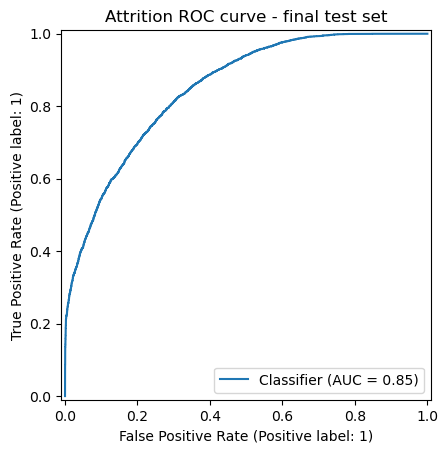

In [6]:
train_scores = evaluate(best_pipeline, X_train, y_train)
validation_scores_final = evaluate(best_pipeline, X_valid, y_valid)
test_scores = evaluate(best_pipeline, X_test, y_test)
print('TRAINING PERFORMANCE')
print(train_scores)
print('VALIDATION PERFORMANCE')
print(validation_scores_final)
print('FINAL UNBIASED TEST PERFORMANCE')
print(test_scores)
test_probabilities = best_pipeline.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)
print(classification_report(y_test, test_predictions, target_names=['Stayed', 'Left'], zero_division=0))
print('confusion matrix:\n', confusion_matrix(y_test, test_predictions))
RocCurveDisplay.from_predictions(y_test, test_probabilities)
plt.title('Attrition ROC curve - final test set')
plt.show()

## Feature importance

Importance is associative, not causal. The transformed feature names are recovered from the fitted preprocessor when the selected estimator exposes coefficients or tree importances.

In [7]:
fitted_preprocessor = best_pipeline.named_steps['preprocessor']
transformed_names = fitted_preprocessor.get_feature_names_out()
selected_estimator = best_pipeline.named_steps['model']
if hasattr(selected_estimator, 'feature_importances_'):
    importance_values = selected_estimator.feature_importances_
elif hasattr(selected_estimator, 'coef_'):
    importance_values = np.abs(selected_estimator.coef_[0])
else:
    importance_values = np.zeros(len(transformed_names))
importance_df = pd.DataFrame({'feature': transformed_names, 'importance': importance_values}).sort_values('importance', ascending=False).head(15)
display(importance_df)

,feature,importance
37,categorical__Marital Status_Single,0.092807
40,categorical__Job Level_Senior,0.092451
39,categorical__Job Level_Mid,0.078731
38,categorical__Job Level_Entry,0.073840
44,categorical__Remote Work_No,0.065355
35,categorical__Marital Status_Divorced,0.042598
17,categorical__Work-Life Balance_Fair,0.034127
36,categorical__Marital Status_Married,0.031563
10,categorical__Gender_Male,0.031370
34,categorical__Education Level_PhD,0.030884


## Save complete inference artifact

The prediction helper checks the fitted class order rather than assuming probability column position. Attrition probability is the probability of the class labeled `Left`; retention is its complement.

In [8]:
model_classes = list(best_pipeline.named_steps['model'].classes_)
assert model_classes == [0, 1], model_classes
artifact = {
    'artifact_type': 'retention_classifier',
    'version': 1,
    'source_file': DATA_PATH.name,
    'pipeline': best_pipeline,
    'feature_columns': feature_columns,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'target_column': 'Attrition',
    'class_mapping': {'Stayed': 0, 'Left': 1},
    'model_classes': model_classes,
    'selected_model': best_name,
    'validation_scores': candidate_scores[best_name],
    'final_test_scores': test_scores,
    'risk_thresholds': {'low_max': 0.30, 'medium_max': 0.60},
    'leakage_exclusions': id_columns + post_outcome_columns,
}
artifact_path = MODEL_DIR / 'retention_model.joblib'
joblib.dump(artifact, artifact_path)
assert artifact_path.exists() and artifact_path.stat().st_size > 0
loaded_artifact = joblib.load(artifact_path)

def predict_employee(raw_employee, saved_artifact=loaded_artifact):
    frame = pd.DataFrame([raw_employee]) if isinstance(raw_employee, dict) else raw_employee.copy()
    pipeline = saved_artifact['pipeline']
    probabilities = pipeline.predict_proba(frame)
    classes = list(pipeline.named_steps['model'].classes_)
    attrition_index = classes.index(saved_artifact['class_mapping']['Left'])
    attrition_probability = float(probabilities[0, attrition_index])
    prediction = int(pipeline.predict(frame)[0])
    thresholds = saved_artifact['risk_thresholds']
    risk_level = 'Low' if attrition_probability < thresholds['low_max'] else 'Medium' if attrition_probability < thresholds['medium_max'] else 'High'
    return {'attrition_prediction': prediction, 'attrition_probability': attrition_probability, 'retention_probability': 1.0 - attrition_probability, 'risk_level': risk_level}

smoke_input = X_test.iloc[0].to_dict()
smoke_result = predict_employee(smoke_input)
assert set(smoke_result) == {'attrition_prediction', 'attrition_probability', 'retention_probability', 'risk_level'}
assert abs(smoke_result['attrition_probability'] + smoke_result['retention_probability'] - 1.0) < 1e-9
print('saved:', artifact_path)
print('selected model:', loaded_artifact['selected_model'])
print('smoke prediction:', smoke_result)

saved: o:\Ps135\Ps135\ml\models\retention_model.joblib
selected model: xgboost
smoke prediction: {'attrition_prediction': 0, 'attrition_probability': 0.49591976404190063, 'retention_probability': 0.5040802359580994, 'risk_level': 'Medium'}
